# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
import re
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split, cross_validate, KFold
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, make_scorer, hamming_loss

In [2]:
# option to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 5000)

# Import Data

In [3]:
df = pd.read_csv('train.csv')

# Preprocessing

In [4]:
df['processed_text'] = df['comment_text'].apply(lambda x: re.sub(r'\n', ' ', str(x)))
df['processed_text'] = df['processed_text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s.,!?;:()-]', '', str(x)))
df['processed_text'] = df['processed_text'].str.lower()
df['processed_text'] = df['processed_text'].apply(lambda x: contractions.fix(str(x)))
df['processed_text'] = df['processed_text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
df['tokens'] = df['processed_text'].apply(lambda x: nltk.word_tokenize(str(x)))
STOPWORDS = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in STOPWORDS])
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df['processed_text'] = df['tokens'].apply(lambda x: re.sub(r'\s+', ' ', " ".join(x)).strip())

df['word_count'] = df['comment_text'].apply(lambda x: len(x.split())) 
df['unique_word_count'] = df['comment_text'].apply(lambda x: len(set(x.split())))
df['char_count'] = df['comment_text'].apply(lambda x: len(x))
df['upper_chars'] = df['comment_text'].apply(lambda x: sum([1 if char.isupper() else 0 for char in x]))
df['upper_words'] = df['comment_text'].apply(lambda x: sum([1 if word.isupper() else 0 for word in x.split()]))
df['punctuation_count'] = df['comment_text'].apply(lambda x: sum([1 if char in string.punctuation else 0 for char in x]))
df['biggest_word'] = df['comment_text'].apply(lambda x: len(max(x.split(), key=len)))
df['perc_punctuation'] = df['punctuation_count'] / (df['punctuation_count'] + df['char_count'])
df['perc_upper_chars'] = df['upper_chars'] / df['char_count']
df['perc_upper_words'] = df['upper_words'] / df['word_count']
df['avg_word_size'] = df['char_count'] / df['word_count']

In [5]:
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,processed_text,tokens,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation edits made username hardcore metal...,"[explanation, edits, made, username, hardcore,...",43,41,264,17,2,10,16,0.036496,0.064394,0.046512,6.139535
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww match background colour seemingly stuck t...,"[daww, match, background, colour, seemingly, s...",17,17,112,8,1,12,10,0.096774,0.071429,0.058824,6.588235
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man really trying edit war guy constantly ...,"[hey, man, really, trying, edit, war, guy, con...",42,39,233,4,0,6,11,0.025105,0.017167,0.000000,5.547619
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,make real suggestion improvement wondered sect...,"[make, real, suggestion, improvement, wondered...",113,82,622,11,5,21,44,0.032659,0.017685,0.044248,5.504425
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,sir hero chance remember page,"[sir, hero, chance, remember, page]",13,13,67,2,0,5,8,0.069444,0.029851,0.000000,5.153846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,second time asking view completely contradicts...,"[second, time, asking, view, completely, contr...",47,44,295,2,0,18,13,0.057508,0.006780,0.000000,6.276596
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,ashamed horrible thing put talk page 128611993,"[ashamed, horrible, thing, put, talk, page, 12...",18,18,99,2,0,4,12,0.038835,0.020202,0.000000,5.500000
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,spitzer umm actual article prostitution ring c...,"[spitzer, umm, actual, article, prostitution, ...",12,12,81,4,0,4,12,0.047059,0.049383,0.000000,6.750000
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,look like actually put speedy first version de...,"[look, like, actually, put, speedy, first, ver...",25,23,116,2,1,1,8,0.008547,0.017241,0.040000,4.640000


# Train Test Split

In [6]:
input_string = ['comment_text']

numerical_features = ['word_count', 'unique_word_count', 'char_count', 'upper_chars', 'upper_words', 'punctuation_count', 'biggest_word', 
            'perc_punctuation', 'perc_upper_chars', 'perc_upper_words', 'avg_word_size']

targets = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [7]:
X = df[numerical_features]
y = df[targets]

comment_text_all = df[input_string]

In [8]:
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(X, y, comment_text_all, test_size=0.2, random_state=10)

# Logistic Regression

In [9]:
base_classifier = LogisticRegression(random_state=42, solver='liblinear')
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

param_grid = {
    'estimator__C': [0.1, 1.0, 10.0],  # Regularization strength for LogisticRegression
    'estimator__penalty': ['l1', 'l2'], # Regularization type
}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=2,             # Higher verbosity shows more progress
    n_jobs=-1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=LogisticRegression(random_state=42,
                                                                        solver='liblinear'),
                                           n_jobs=-1),
             n_jobs=-1,
             param_grid={'estimator__C': [0.1, 1.0, 10.0],
                         'estimator__penalty': ['l1', 'l2']},
             return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=2)

In [10]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {'estimator__C': 0.1, 'estimator__penalty': 'l1'}
Best cross-validation score (Micro F1): 0.0857


In [11]:
best_multi_label_model = grid_search.best_estimator_

In [12]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0354
Micro F1 on test set: 0.0894


In [13]:
y_pred_df = pd.DataFrame(y_pred_best, columns=[f'pred_{col}' for col in targets], index=X_test.index)
X_test_with_text = X_test.copy()
X_test_with_text['comment_text'] = text_test
results_df = pd.concat([X_test_with_text, y_pred_df, y_test], axis=1)

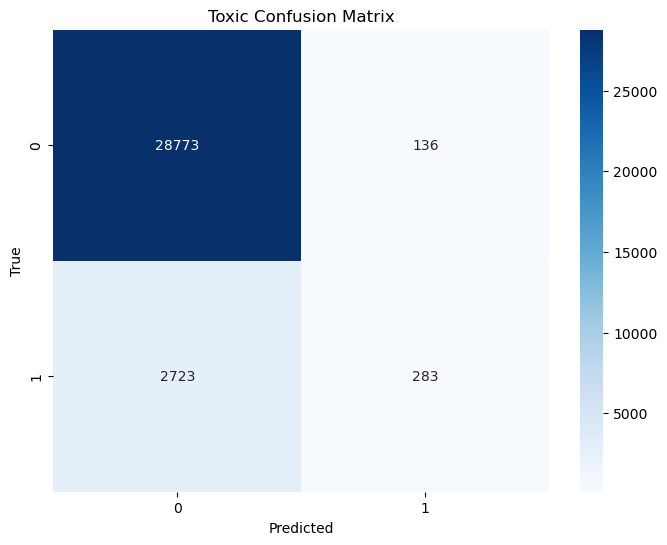

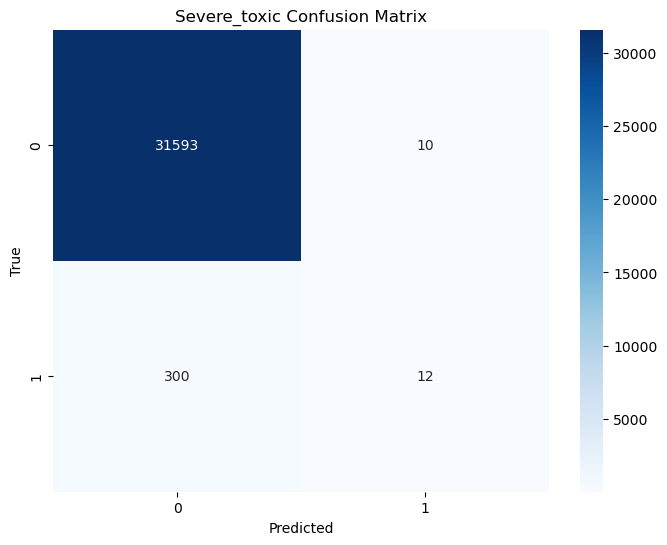

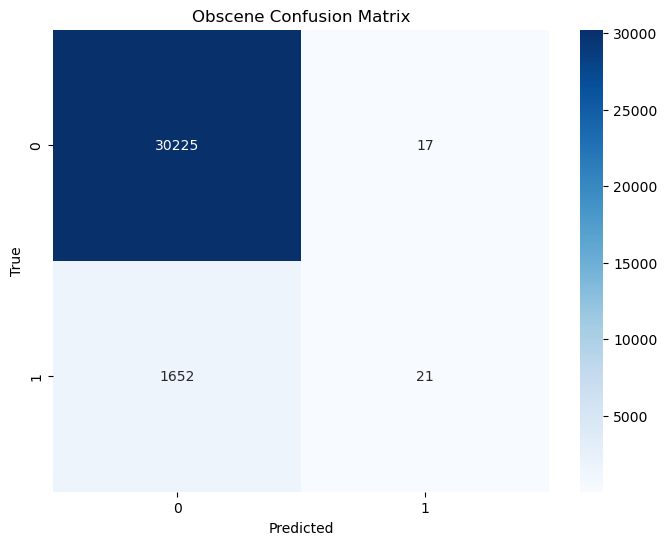

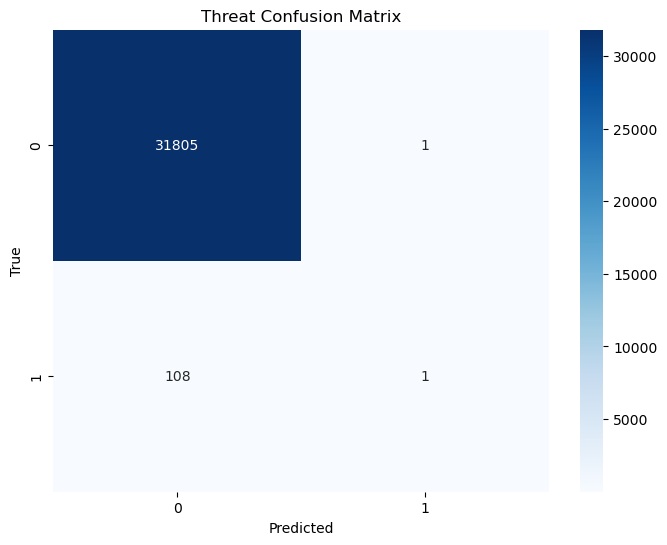

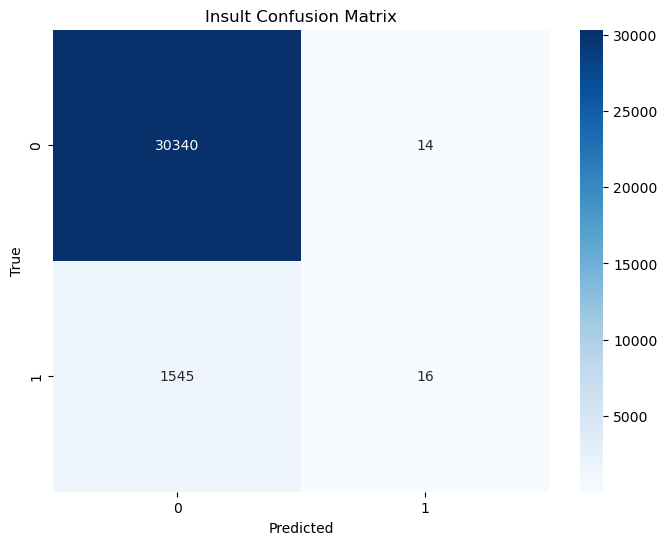

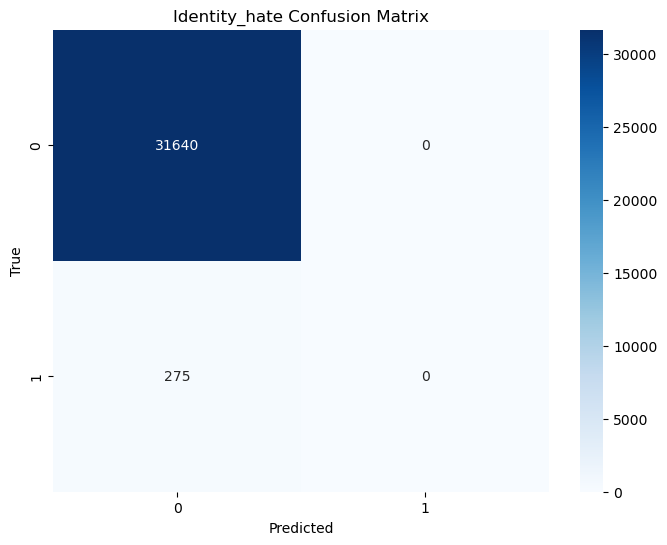

In [14]:
for col in targets:
    y_true = results_df[col]
    y_pred = results_df['pred_' + col]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{col.capitalize()} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Random Forest

In [15]:
base_classifier = RandomForestClassifier(random_state=42)
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

# empty grid just to create a simple training test to check the time required to fit the model
param_grid = {

}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=2,             # Higher verbosity shows more progress
    n_jobs=-1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=RandomForestClassifier(random_state=42),
                                           n_jobs=-1),
             n_jobs=-1, param_grid={}, return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=2)

In [16]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {}
Best cross-validation score (Micro F1): 0.1493


In [17]:
best_multi_label_model = grid_search.best_estimator_

In [18]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0377
Micro F1 on test set: 0.1547


In [19]:
y_pred_df = pd.DataFrame(y_pred_best, columns=[f'pred_{col}' for col in targets], index=X_test.index)
X_test_with_text = X_test.copy()
X_test_with_text['comment_text'] = text_test
results_df = pd.concat([X_test_with_text, y_pred_df, y_test], axis=1)

In [20]:
y_train_df = pd.DataFrame(y_train, columns=[col for col in targets], index=X_train.index)
X_train_with_text = X_train.copy()
X_train_with_text['comment_text'] = text_train
pd.concat([X_train_with_text, y_train_df], axis=1).query('identity_hate==1').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
156151,3,3,20,1,0,2,10,0.090909,0.050000,0.000000,6.666667,Dylan's a pedophile.,1,0,1,0,1,1
130806,3,3,40,1,0,3,22,0.069767,0.025000,0.000000,13.333333,Niggers \n\nniggers everywhere69.233.92.38,1,0,0,0,1,1
159029,3,3,19,2,0,1,10,0.050000,0.105263,0.000000,6.333333,Death to Musulmans!,1,0,0,1,0,1
55371,3,3,20,2,0,0,6,0.000000,0.100000,0.000000,6.666667,Faggot \n\nEnough said,1,0,1,0,1,1
13539,4,4,23,4,0,1,8,0.041667,0.173913,0.000000,5.750000,User:Abd is Muslim Scum,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53408,834,4,5000,556,0,277,9,0.052492,0.111200,0.000000,5.995204,BunkSteve is gay! BunkSteve is gay! BunkSteve ...,1,1,0,0,1,1
39610,842,13,4985,3786,771,3,11,0.000601,0.759478,0.915677,5.920428,'''JForget FUCK YOU FAGGOT GAY ASS CHINK NIGGE...,1,1,1,0,1,1
10507,887,6,4969,178,0,178,8,0.034583,0.035822,0.000000,5.602029,Fan-1967 is a nigger licker \n\nFan-1967 is a...,1,0,1,0,1,1
32400,1238,10,4981,3742,1238,0,12,0.000000,0.751255,1.000000,4.023425,THAT WAS REALLY MILLESECONDS WASNT IT BITCH \n...,1,0,1,0,1,1


In [21]:
results_df.query('identity_hate==1').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
113646,2,2,18,17,2,0,15,0.000000,0.944444,1.000000,9.000000,HA GAAAAAAAAAYYYYY,0,0,0,0,1,0,1,0,0,0,0,1
113581,3,3,20,1,0,2,7,0.090909,0.050000,0.000000,6.666667,"hrm \n\nHello, faggot.",0,0,0,0,0,0,1,0,1,0,1,1
141549,4,4,36,1,0,4,14,0.100000,0.027778,0.000000,9.000000,Jew supremacist liar. 146.179.213.55,0,0,0,0,0,0,1,0,0,0,0,1
110115,4,4,31,0,0,1,11,0.031250,0.000000,0.000000,7.750000,homosexuals are all pedophiles.,0,0,0,0,0,0,1,0,0,0,0,1
6212,4,4,24,0,0,2,7,0.076923,0.000000,0.000000,6.000000,"fuck your couch, nigger!",0,0,0,0,0,0,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25825,536,288,2890,13,3,75,16,0.025295,0.004498,0.005597,5.391791,"ok, if you consider yourself the master of log...",0,0,0,0,0,0,1,0,1,0,1,1
48105,771,29,4999,3893,743,301,12,0.056792,0.778756,0.963684,6.483787,intervei CAN STILL POST WITH THIS COMPUTER...I...,1,1,1,0,1,0,1,1,1,0,1,1
10769,909,5,5000,3183,909,0,9,0.000000,0.636600,1.000000,5.500550,TOMMY2010 IS A NIGGER TOMMY2010 IS A NIGGER TO...,1,1,0,0,0,0,1,0,0,0,1,1
55160,929,29,3882,2836,929,31,34,0.007922,0.730551,1.000000,4.178687,ANYONE WHO SUPPORTS THIS IS FUCKING SICK. MEN ...,1,0,1,0,0,0,1,1,1,1,1,1


In [22]:
results_df.query('pred_toxic != toxic').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
111531,2,2,39,2,0,24,32,0.380952,0.051282,0.000000,19.500000,Stupid Liberals!!!!!!!!!!!!!!!!!!!!!!!!,0,0,0,0,0,0,1,0,0,0,1,0
113646,2,2,18,17,2,0,15,0.000000,0.944444,1.000000,9.000000,HA GAAAAAAAAAYYYYY,0,0,0,0,1,0,1,0,0,0,0,1
20953,2,2,30,24,2,0,23,0.000000,0.800000,1.000000,15.000000,O\n DIEEEEEEEEEEEEEEEEEEEEE,0,0,0,0,0,0,1,0,0,0,0,0
120214,2,2,25,1,0,14,20,0.358974,0.040000,0.000000,12.500000,Fuck offfff.!!!!!!!!!!!!!,0,0,0,0,0,0,1,1,1,0,0,0
44406,2,2,26,13,2,3,20,0.103448,0.500000,1.000000,13.000000,HELLO DICKHEAD68.75.164.65,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18100,833,480,4858,97,13,168,20,0.033426,0.019967,0.015606,5.831933,You swine. You vulgar little maggot. You worth...,0,0,0,0,0,0,1,1,1,0,1,0
47715,834,2,5000,834,0,0,5,0.000000,0.166800,0.000000,5.995204,Block Block Block Block Block Block Block Bloc...,1,0,0,0,0,0,0,0,0,0,0,0
75165,953,5,5000,3810,953,238,8,0.045437,0.762000,1.000000,5.246590,IN THE NAME OF YTMND!IN THE NAME OF YTMND!IN T...,1,1,1,0,1,0,0,0,0,0,0,0
11956,1000,1,4999,0,0,0,4,0.000000,0.000000,0.000000,4.999000,fish fish fish fish fish fish fish fish fish f...,1,0,0,0,1,0,0,0,0,0,0,0


In [23]:
results_df.query('pred_severe_toxic != severe_toxic').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
120214,2,2,25,1,0,14,20,0.358974,0.040000,0.000000,12.500000,Fuck offfff.!!!!!!!!!!!!!,0,0,0,0,0,0,1,1,1,0,0,0
63195,3,3,26,0,0,0,15,0.000000,0.000000,0.000000,8.666667,fuck you \n\nyoufuckingidiot,0,0,0,0,0,0,1,1,1,0,1,0
24845,3,3,32,1,0,4,21,0.111111,0.031250,0.000000,10.666667,You mother fucker!126.12.157.168,0,0,0,0,0,0,1,1,1,0,1,0
143162,4,4,21,18,4,0,6,0.000000,0.857143,1.000000,5.250000,FUCK YOU KANSAS BİTCH,1,0,0,0,0,0,1,1,1,0,1,0
11699,4,4,25,0,0,0,12,0.000000,0.000000,0.000000,6.250000,burn in hell motherfucker,0,0,0,0,0,0,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75165,953,5,5000,3810,953,238,8,0.045437,0.762000,1.000000,5.246590,IN THE NAME OF YTMND!IN THE NAME OF YTMND!IN T...,1,1,1,0,1,0,0,0,0,0,0,0
148492,965,26,4999,3377,965,658,13,0.116316,0.675535,1.000000,5.180311,YOU SHOULD ALL RUE THE DAY YOU WERE BORN!!!! I...,1,0,0,0,1,0,1,1,0,0,1,0
22378,1001,4,5000,334,334,333,7,0.062441,0.066800,0.333666,4.995005,I fuck niggas! I fuck niggas! I fuck niggas! I...,1,0,0,0,0,0,1,1,1,0,1,1
127125,1104,3,4969,0,0,0,4,0.000000,0.000000,0.000000,4.500906,fuck you \n\nfuck you fuck you fuck you fuck ...,1,0,0,0,1,0,1,1,1,0,1,0


In [24]:
results_df.query('pred_obscene != obscene').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
120214,2,2,25,1,0,14,20,0.358974,0.040000,0.000000,12.500000,Fuck offfff.!!!!!!!!!!!!!,0,0,0,0,0,0,1,1,1,0,0,0
23611,2,2,19,0,0,1,9,0.050000,0.000000,0.000000,9.500000,questions cuntface!,0,0,0,0,0,0,0,0,1,0,1,0
33302,3,3,20,1,0,0,8,0.000000,0.050000,0.000000,6.666667,fuck \n\nfuckBold text,0,0,0,0,0,0,1,0,1,0,0,0
113581,3,3,20,1,0,2,7,0.090909,0.050000,0.000000,6.666667,"hrm \n\nHello, faggot.",0,0,0,0,0,0,1,0,1,0,1,1
99337,3,3,22,9,1,3,8,0.120000,0.409091,0.333333,7.333333,Fuck you... \n\nASSSSSSS,0,0,0,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75165,953,5,5000,3810,953,238,8,0.045437,0.762000,1.000000,5.246590,IN THE NAME OF YTMND!IN THE NAME OF YTMND!IN T...,1,1,1,0,1,0,0,0,0,0,0,0
22378,1001,4,5000,334,334,333,7,0.062441,0.066800,0.333666,4.995005,I fuck niggas! I fuck niggas! I fuck niggas! I...,1,0,0,0,0,0,1,1,1,0,1,1
127125,1104,3,4969,0,0,0,4,0.000000,0.000000,0.000000,4.500906,fuck you \n\nfuck you fuck you fuck you fuck ...,1,0,0,0,1,0,1,1,1,0,1,0
132485,1135,11,4994,1248,227,679,9,0.119690,0.249900,0.200000,4.400000,Do I know you? ==BeCauSe You aRe a FGGT! == Do...,1,0,0,0,0,0,1,0,1,0,1,0


In [25]:
results_df.query('pred_threat != threat').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
145200,4,4,21,13,3,5,6,0.192308,0.619048,0.750000,5.250000,ASK YOUR MOTHER <<<>>,0,0,0,1,0,0,1,0,0,0,0,0
11699,4,4,25,0,0,0,12,0.000000,0.000000,0.000000,6.250000,burn in hell motherfucker,0,0,0,0,0,0,1,1,1,1,1,0
157010,5,5,23,0,0,0,7,0.000000,0.000000,0.000000,4.600000,of killing all the jews,0,0,0,0,0,0,1,0,0,1,0,1
129815,6,6,34,1,0,3,13,0.081081,0.029412,0.000000,5.666667,Sitush is an asshole...die you dog,0,0,0,0,0,0,1,0,1,1,1,0
110908,6,6,32,16,4,5,8,0.135135,0.500000,0.666667,5.333333,or else I WOULD DESTROY YOU!!!!!,0,0,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18803,115,82,570,0,0,11,10,0.018933,0.000000,0.000000,4.956522,yeah is that youuu\n\noh i think it is big boi...,0,0,0,0,0,0,1,0,1,1,1,0
38513,182,13,817,636,182,0,11,0.000000,0.778458,1.000000,4.489011,AM GOING TO RAPE YOU IN THE ASS YOU FAT BITCH ...,1,0,1,0,0,0,1,1,1,1,1,1
15562,306,3,2143,1836,306,1,9,0.000466,0.856743,1.000000,7.003268,KILL YOURSELF.\n\nKILL YOURSELF KILL YOURSELF ...,1,0,1,0,0,0,1,1,0,1,0,0
28855,626,5,5000,2347,626,1872,15,0.272410,0.469400,1.000000,7.987220,JIM WALES MUST DIE!!!!!!!!!!!! JIM WALES MUST...,1,1,1,0,1,0,1,1,0,1,0,0


In [26]:
results_df.query('pred_insult != insult').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
23611,2,2,19,0,0,1,9,0.050000,0.000000,0.000000,9.500000,questions cuntface!,0,0,0,0,0,0,0,0,1,0,1,0
113646,2,2,18,17,2,0,15,0.000000,0.944444,1.000000,9.000000,HA GAAAAAAAAAYYYYY,0,0,0,0,1,0,1,0,0,0,0,1
101492,2,2,13,11,2,1,8,0.071429,0.846154,1.000000,6.500000,GONE FISHING.,1,0,0,0,1,0,0,0,0,0,0,0
111531,2,2,39,2,0,24,32,0.380952,0.051282,0.000000,19.500000,Stupid Liberals!!!!!!!!!!!!!!!!!!!!!!!!,0,0,0,0,0,0,1,0,0,0,1,0
113581,3,3,20,1,0,2,7,0.090909,0.050000,0.000000,6.666667,"hrm \n\nHello, faggot.",0,0,0,0,0,0,1,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75165,953,5,5000,3810,953,238,8,0.045437,0.762000,1.000000,5.246590,IN THE NAME OF YTMND!IN THE NAME OF YTMND!IN T...,1,1,1,0,1,0,0,0,0,0,0,0
11956,1000,1,4999,0,0,0,4,0.000000,0.000000,0.000000,4.999000,fish fish fish fish fish fish fish fish fish f...,1,0,0,0,1,0,0,0,0,0,0,0
22378,1001,4,5000,334,334,333,7,0.062441,0.066800,0.333666,4.995005,I fuck niggas! I fuck niggas! I fuck niggas! I...,1,0,0,0,0,0,1,1,1,0,1,1
132485,1135,11,4994,1248,227,679,9,0.119690,0.249900,0.200000,4.400000,Do I know you? ==BeCauSe You aRe a FGGT! == Do...,1,0,0,0,0,0,1,0,1,0,1,0


In [27]:
results_df.query('pred_identity_hate != identity_hate').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
113646,2,2,18,17,2,0,15,0.000000,0.944444,1.000000,9.000000,HA GAAAAAAAAAYYYYY,0,0,0,0,1,0,1,0,0,0,0,1
113581,3,3,20,1,0,2,7,0.090909,0.050000,0.000000,6.666667,"hrm \n\nHello, faggot.",0,0,0,0,0,0,1,0,1,0,1,1
141549,4,4,36,1,0,4,14,0.100000,0.027778,0.000000,9.000000,Jew supremacist liar. 146.179.213.55,0,0,0,0,0,0,1,0,0,0,0,1
110115,4,4,31,0,0,1,11,0.031250,0.000000,0.000000,7.750000,homosexuals are all pedophiles.,0,0,0,0,0,0,1,0,0,0,0,1
39472,4,4,23,0,0,0,11,0.000000,0.000000,0.000000,5.750000,hes a black pieceofshit,0,0,0,0,0,0,1,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48105,771,29,4999,3893,743,301,12,0.056792,0.778756,0.963684,6.483787,intervei CAN STILL POST WITH THIS COMPUTER...I...,1,1,1,0,1,0,1,1,1,0,1,1
96267,799,18,5000,4202,799,0,17,0.000000,0.840400,1.000000,6.257822,BOOTSTOOTS IS A FRIGGEN GAYFAG LOLOOOLBOOTSTOO...,1,1,1,0,1,1,1,0,0,0,1,0
10769,909,5,5000,3183,909,0,9,0.000000,0.636600,1.000000,5.500550,TOMMY2010 IS A NIGGER TOMMY2010 IS A NIGGER TO...,1,1,0,0,0,0,1,0,0,0,1,1
55160,929,29,3882,2836,929,31,34,0.007922,0.730551,1.000000,4.178687,ANYONE WHO SUPPORTS THIS IS FUCKING SICK. MEN ...,1,0,1,0,0,0,1,1,1,1,1,1


In [28]:
results_df.query('pred_toxic == toxic & toxic == 1').sort_values('word_count')

,word_count,unique_word_count,char_count,upper_chars,upper_words,punctuation_count,biggest_word,perc_punctuation,perc_upper_chars,perc_upper_words,avg_word_size,comment_text,pred_toxic,pred_severe_toxic,pred_obscene,pred_threat,pred_insult,pred_identity_hate,toxic,severe_toxic,obscene,threat,insult,identity_hate
110719,4,3,52,46,4,0,17,0.000000,0.884615,1.0,13.000000,FUCKKKKKKKKKK \nFUCKKKKKKKKKK USA FUCKKKKKKK...,1,0,1,0,1,0,1,1,1,0,0,0
68364,4,4,27,0,0,1,8,0.035714,0.000000,0.0,6.750000,guess what? \n\nyour retarded,1,0,1,0,0,0,1,0,0,0,1,0
54122,4,4,21,0,0,0,7,0.000000,0.000000,0.0,5.250000,fuck you cracker nerd,1,0,1,0,1,0,1,0,1,0,1,0
47672,4,2,25,0,0,0,6,0.000000,0.000000,0.0,6.250000,hola fucker \n\nhola fucker,1,0,0,0,0,0,1,0,1,0,0,0
35648,4,4,29,1,0,5,13,0.147059,0.034483,0.0,7.250000,You're a prick. 194.66.175.71,1,1,1,0,1,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76822,1005,5,4014,201,201,0,3,0.000000,0.050075,0.2,3.994030,I am a bad egg I am a bad egg I am a...,1,0,0,0,0,0,1,0,0,0,0,0
2420,1087,5,4999,3913,1087,0,7,0.000000,0.782757,1.0,4.598896,FUCK YOU U USELESS BOT FUCK YOU U USELESS BOT ...,1,1,1,0,1,0,1,1,1,0,1,0
127125,1104,3,4969,0,0,0,4,0.000000,0.000000,0.0,4.500906,fuck you \n\nfuck you fuck you fuck you fuck ...,1,0,0,0,1,0,1,1,1,0,1,0
132485,1135,11,4994,1248,227,679,9,0.119690,0.249900,0.2,4.400000,Do I know you? ==BeCauSe You aRe a FGGT! == Do...,1,0,0,0,0,0,1,0,1,0,1,0


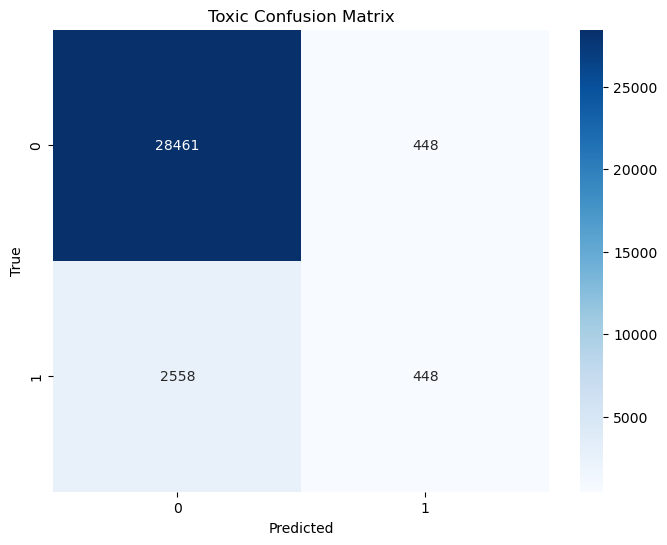

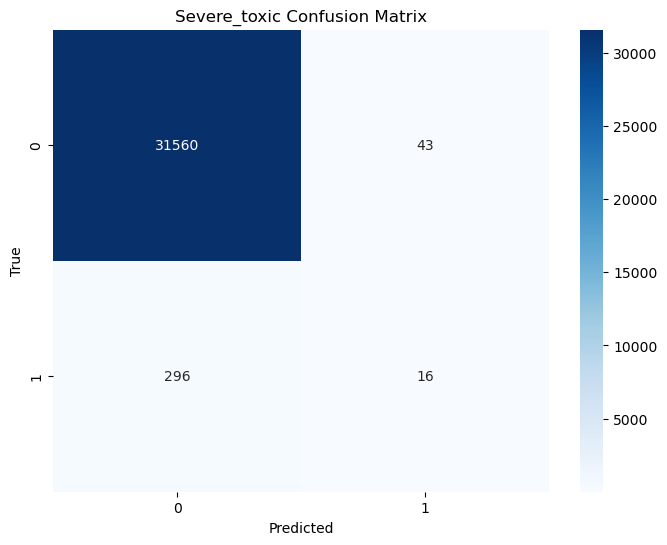

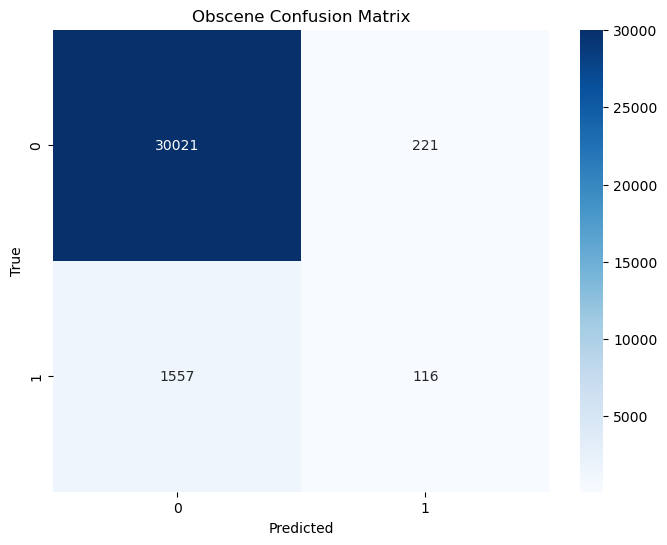

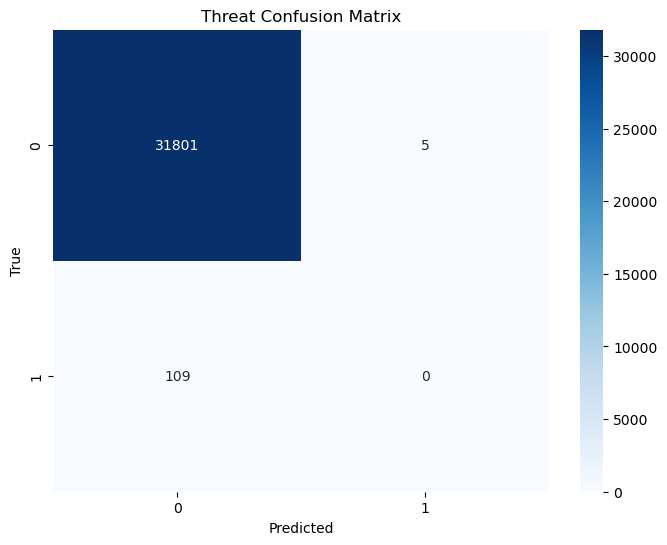

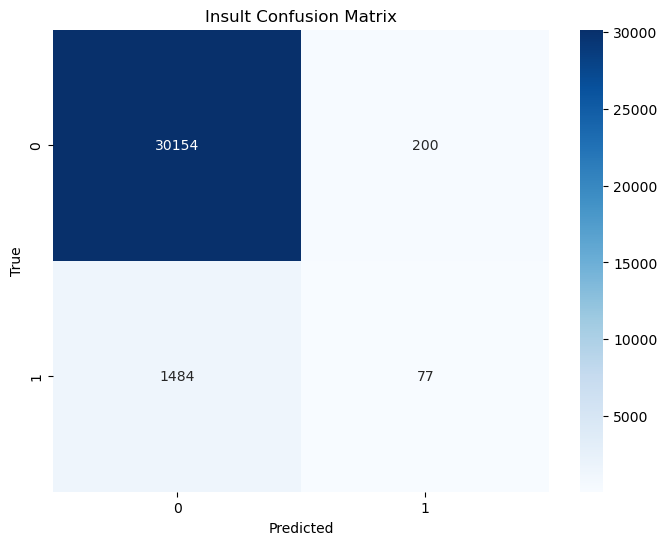

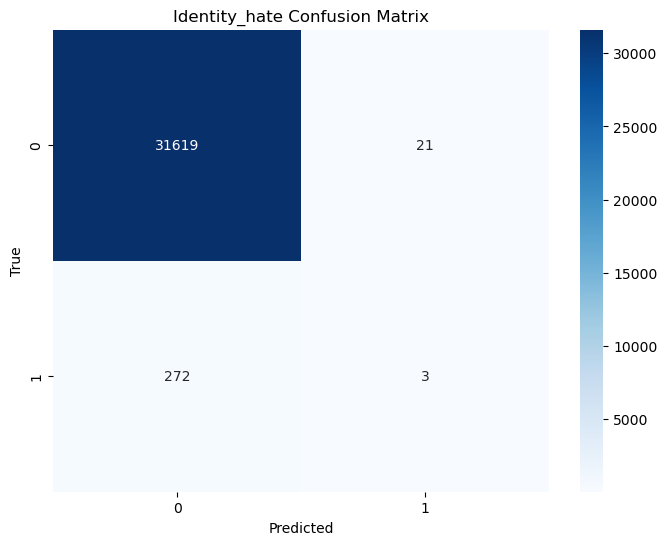

In [29]:
for col in targets:
    y_true = results_df[col]
    y_pred = results_df['pred_' + col]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{col.capitalize()} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# XGBoost

In [30]:
base_classifier = XGBClassifier(objective='binary:logistic', eval_metric='mlogloss', random_state=42)
multi_label_model = OneVsRestClassifier(base_classifier, n_jobs=-1)

# empty grid just to create a simple training test to check the time required to fit the model
param_grid = {

}

f1_micro_scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(
    estimator=multi_label_model,
    param_grid=param_grid,
    scoring=f1_micro_scorer, # Use your multi-label F1-score for optimization
    cv=5,
    verbose=2,             # Higher verbosity shows more progress
    n_jobs=-1,             # Parallelize grid search folds
    return_train_score=True # Useful for checking for overfitting
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5,
             estimator=OneVsRestClassifier(estimator=XGBClassifier(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsample_bynode=None,
                                                                   colsample_bytree=None,
                                                                   device=None,
                                                                   early_stopping_rounds=None,
                                                                   enable_categorical=False,
                                                                   eval_metric='mlogloss',
                                                                   feature_types=None,
                                                                   feature_weights=None,
                                                                   gamma=None,
                                                                   grow_policy=None,
                                                                   importance_t...
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=None,
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=None,
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None, ...),
                                           n_jobs=-1),
             n_jobs=-1, param_grid={}, return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=micro),
             verbose=2)

In [31]:
print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (Micro F1): {grid_search.best_score_:.4f}")


--- Grid Search Results ---
Best parameters found: {}
Best cross-validation score (Micro F1): 0.1347


In [32]:
best_multi_label_model = grid_search.best_estimator_

In [33]:
y_pred_best = best_multi_label_model.predict(X_test)

print(f"Hamming Loss on test set: {hamming_loss(y_test, y_pred_best):.4f}")
print(f"Micro F1 on test set: {f1_score(y_test, y_pred_best, average='micro'):.4f}")

Hamming Loss on test set: 0.0361
Micro F1 on test set: 0.1347


In [34]:
y_pred_df = pd.DataFrame(y_pred_best, columns=[f'pred_{col}' for col in targets], index=X_test.index)
X_test_with_text = X_test.copy()
X_test_with_text['comment_text'] = text_test
results_df = pd.concat([X_test_with_text, y_pred_df, y_test], axis=1)

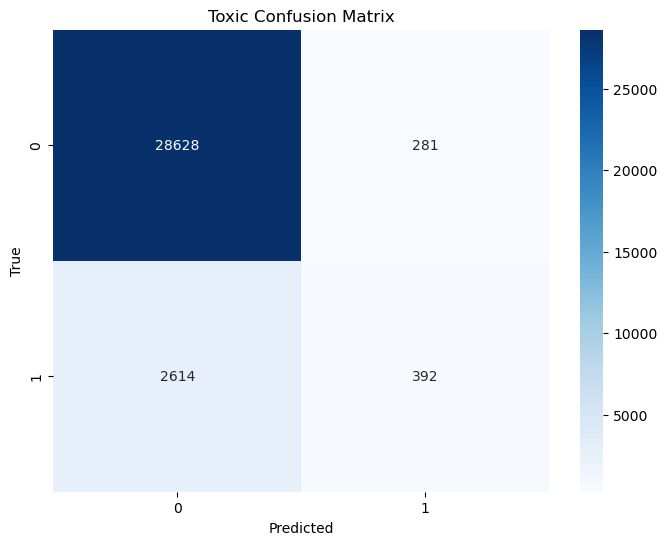

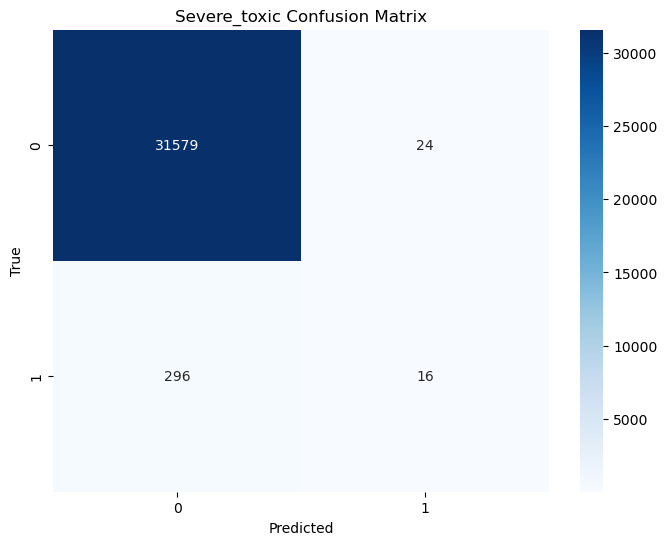

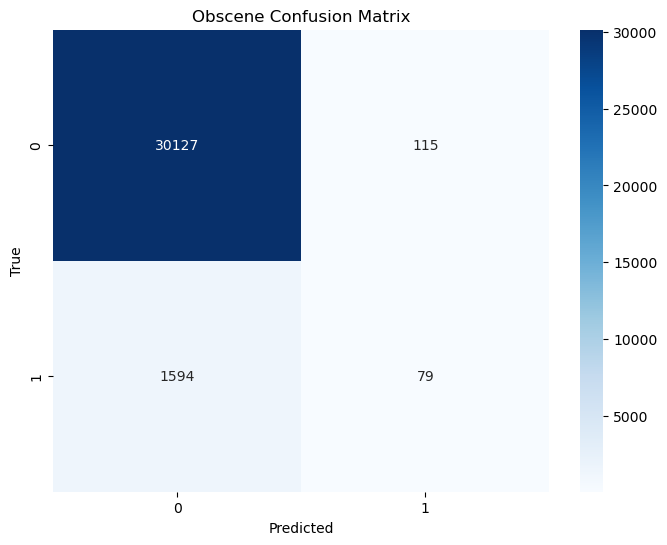

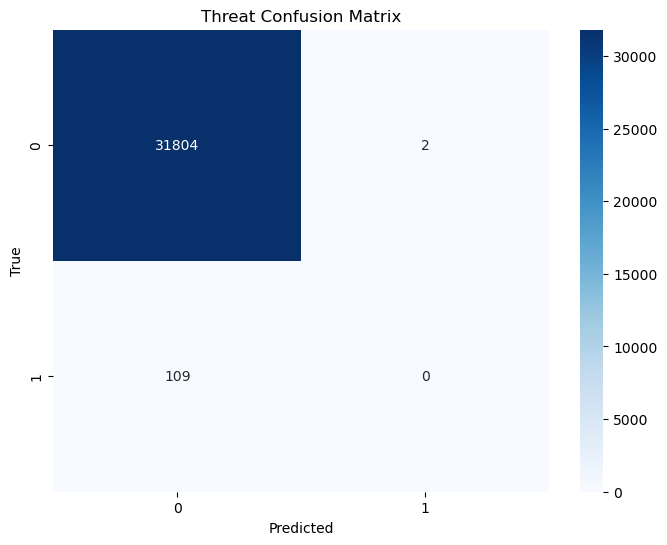

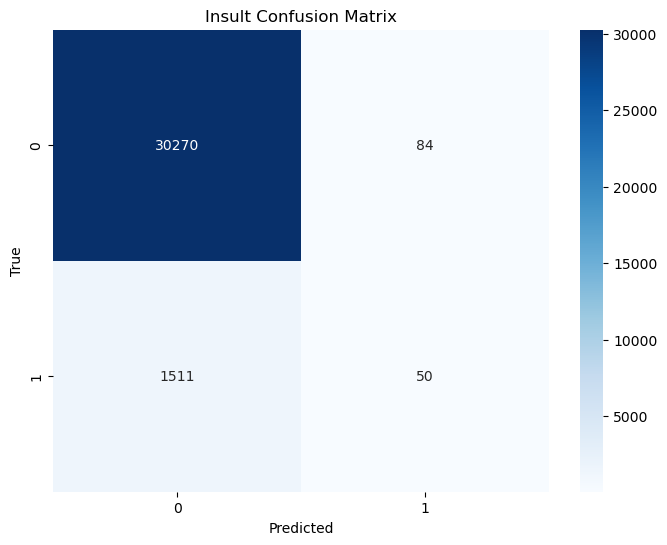

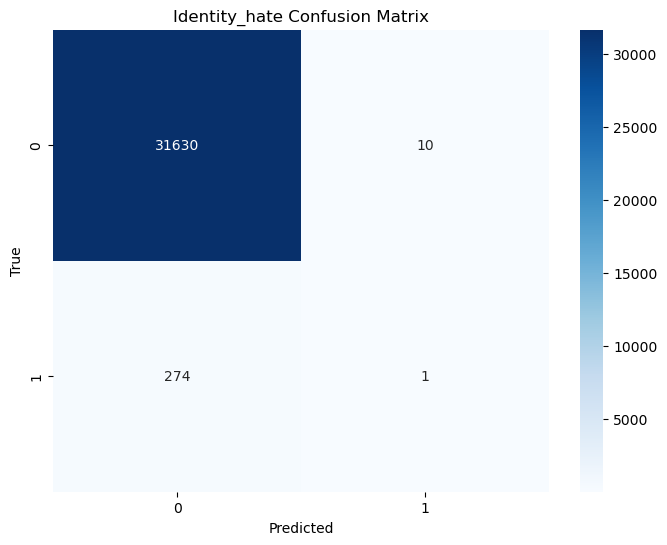

In [35]:
for col in targets:
    y_true = results_df[col]
    y_pred = results_df['pred_' + col]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{col.capitalize()} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Notes

As expected the results are not very good. Using only the string information of the comments is not enough to identify the toxicity in the messages.

I will try to add information using bag_of_words. And Also tf-idf